## 生成模擬資料

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE


In [32]:
# rng = np.random.default_rng(42)
# eps = 1e-8

# p = 100
# configs = [{'label':'linear', 'n':500, 'rho_xx':0.95, 'rho_xy':0.2, 'mean_shift':-4, 'std_x':1, 'std_y':0.8, "amp":1.5, "a":1, "b":-3}, 
#            {'label':'poly', 'n':500, 'rho_xx':0.65, 'rho_xy':-0.5, 'mean_shift':0, 'std_x':1.2, 'std_y':1.2, "amp":1.0, "a":1.2, "b":0},
#            {'label':'trig', 'n':500, 'rho_xx':0.3, 'rho_xy':0.8, 'mean_shift':4, 'std_x':0.6, 'std_y':1, "amp":2, "a":1.5, "b":3}]

# frames = []
# for k, cfg in enumerate(configs, 1):
#     m = p+1
#     Corr = np.full((m ,m), cfg['rho_xx'])
#     np.fill_diagonal(Corr, 1)
#     Corr[-1, :-1] = cfg['rho_xy']
#     Corr[:-1, -1] = cfg['rho_xy']

#     stds = np.r_[np.repeat(cfg['std_x'], p), cfg['std_y']]
#     D = np.diag(stds)
#     Sigma = D@Corr@D

#     # 正定修補
#     w, V = np.linalg.eigh(Sigma)
#     w = np.clip(w, 1e-6, None)
#     Sigma = (V*w)@V.T

#     mu = np.r_[np.repeat(cfg['mean_shift'], p), cfg['mean_shift']]
#     Z = rng.multivariate_normal(mu, Sigma, size=cfg['n'])

#     X = Z[:, :p]
#     y = Z[:, p]

#     X_obs = X.copy()

#     if cfg['label'] == 'poly':
#         idx_sq = [10, 30, 50]
#         idx_ix = (0, 1)
#         p_sq = [(X[:, i]**2) for i in idx_sq]
#         p_ix = X[:, idx_ix[0]]*X[:, idx_ix[1]]
#         p_all = p_sq+[p_ix]
#         for i, s in zip(idx_sq+[20], p_all):
#             z = (s-s.mean())/(s.std()+eps)
#             X_obs[:, i] = cfg["amp"]*z

#     if cfg['label'] == 'trig':
#         idx_trig = [(5, 'sin'), (15, 'cos'), (25, 'mix')]  # X6, X16, X26
#         for i, kind in idx_trig:
#             if kind == 'sin':
#                 t = np.sin(X[:, i])
#             elif kind == 'cos':
#                 t = np.cos(0.8*X[:, i])
#             else:
#                 t = np.sin(X[:, 1]+0.5*X[:, i])  # 混合
#             z = (t-t.mean())/(t.std()+eps)
#             X_obs[:, i] = cfg["amp"]*z

#     df = pd.DataFrame(X_obs, columns=[f'X{i+1}' for i in range(p)])
#     df['y_conti'] = y

#     logits = cfg["a"]*y+cfg["b"]
#     prob = 1/(1+np.exp(-logits))
#     df['y_binary'] = (rng.uniform(size=len(df))<prob).astype(int)
#     df['group'] = cfg['label']
#     frames.append(df)

# data = pd.concat(frames, ignore_index=True)

In [33]:
rng = np.random.default_rng(42)
eps = 1e-8

p = 100
frac_poly = 0.4
frac_trig = 0.4
configs = [{'label':'linear', 'n':500, 'rho_xx':0.95, 'rho_xy':0.2, 'mean_shift':-4, 'std_x':1, 'std_y':0.8, "amp":1, "a":-0.2, "b":-0.2}, 
           {'label':'poly', 'n':500, 'rho_xx':0.65, 'rho_xy':-0.5, 'mean_shift':0, 'std_x':1.2, 'std_y':1.2, "amp":2.0, "a":0.4, "b":0},
           {'label':'trig', 'n':500, 'rho_xx':0.3, 'rho_xy':0.8, 'mean_shift':4, 'std_x':0.6, 'std_y':1, "amp":2.5, "a":0.1, "b":0.2}]

frames = []
for k, cfg in enumerate(configs, 1):
    m = p+1
    Corr = np.full((m, m), cfg['rho_xx'])
    np.fill_diagonal(Corr, 1)
    Corr[-1, :-1] = cfg['rho_xy']
    Corr[:-1, -1] = cfg['rho_xy']

    stds = np.r_[np.repeat(cfg['std_x'], p), cfg['std_y']]
    D = np.diag(stds)
    Sigma = D@Corr@D

    # 正定修補
    w, V = np.linalg.eigh(Sigma)
    w = np.clip(w, 1e-6, None)
    Sigma = (V*w)@V.T

    mu = np.r_[np.repeat(cfg['mean_shift'], p), cfg['mean_shift']]
    Z = rng.multivariate_normal(mu, Sigma, size=cfg['n'])

    X = Z[:, :p]
    y = Z[:, p]
    X_obs = X.copy()

    if cfg['label'] == 'poly':
        k_non = int(round(p*frac_poly))
        idx = np.linspace(0, p-1, num=k_non, dtype=int)
        half = k_non//2
        T1 = X[:, idx[:half]]**2
        T2 = X[:, idx[half:k_non]]**3
        T1 = (T1-T1.mean(0))/(T1.std(0)+eps)
        T2 = (T2-T2.mean(0))/(T2.std(0)+eps)
        X_obs[:, idx[:half]] = cfg['amp']*T1
        X_obs[:, idx[half:k_non]] = cfg['amp']*T2
        pairs_ = idx[::2][:k_non//4]
        for i in pairs_:
            j = (i+1)%p
            t = X[:, i]*X[:,j]
            z = (t-t.mean())/(t.std()+eps)
            X_obs[:, i] = cfg["amp"]*z

    if cfg['label'] == 'trig':
        k_non = int(round(p*frac_trig))
        idx = np.linspace(0, p-1, num=k_non, dtype=int)
        third = max(1, k_non//3)
        i1 = idx[:third]
        i2 = idx[third:2*third]
        i3 = idx[2*third:k_non]
        S1 = np.sin(X[:, i1])
        C2 = np.cos(0.8*X[:, i2])
        S3 = np.sin(X[:, i3]+0.5*X[:, (i3+1)%p])
        for block in (S1, C2, S3):
            block -= block.mean(0)
            block /= (block.std(0)+eps)
        T2 = (T2-T2.mean(0))/(T2.std(0)+eps)
        X_obs[:, i1] = cfg["amp"]*S1
        X_obs[:, i2] = cfg["amp"]*C2
        X_obs[:, i3] = cfg["amp"]*S3

    df = pd.DataFrame(X_obs, columns=[f'X{i+1}' for i in range(X_obs.shape[1])])
    df['y_conti'] = y

    logits = cfg["a"]*y+cfg["b"]
    prob = 1/(1+np.exp(-logits))
    df['y_binary'] = (rng.uniform(size=len(df))<prob).astype(int)
    df['group'] = cfg['label']
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
print(data.groupby("group")["y_binary"].mean())

group
linear    0.644
poly      0.512
trig      0.642
Name: y_binary, dtype: float64


In [34]:
data

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X94,X95,X96,X97,X98,X99,X100,y_conti,y_binary,group
0,-4.132656,-4.034711,-4.069552,-4.012707,-4.251853,-4.118396,-4.690228,-4.375615,-4.492534,-4.126158,...,-4.254302,-4.444565,-4.306496,-4.228754,-4.476662,-4.083745,-4.407986,-4.864393,1,linear
1,-5.019707,-5.365852,-5.397459,-5.602813,-5.457476,-5.121880,-5.316252,-5.342888,-5.148427,-4.934305,...,-5.450104,-5.251996,-6.069397,-5.249519,-5.208546,-5.126032,-5.204191,-4.493474,0,linear
2,-4.153804,-4.548141,-4.206143,-3.822426,-3.883242,-3.823074,-4.366626,-4.057430,-4.017438,-3.971733,...,-3.849137,-4.086597,-3.756277,-4.087797,-3.861696,-3.777078,-3.863813,-3.510912,1,linear
3,-3.929308,-3.856792,-3.699859,-3.773893,-3.736561,-3.554277,-3.371539,-3.514151,-3.868615,-3.792072,...,-3.267275,-3.902080,-3.683562,-3.699186,-4.059673,-3.772678,-3.623362,-3.993737,1,linear
4,-4.887089,-4.028260,-4.299598,-4.074515,-4.243070,-4.654626,-4.957813,-4.842468,-4.046203,-4.460014,...,-4.212560,-4.282438,-4.471305,-4.661115,-4.861462,-4.471436,-4.237133,-4.294174,1,linear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,-2.327597,4.400811,-2.576293,3.790832,4.317059,-2.322418,4.205037,-0.746625,5.160183,4.237534,...,3.579443,4.723499,3.928274,2.912568,3.997825,4.478443,3.162839,5.763336,1,trig
1496,-1.946054,4.613390,-2.584399,3.591543,4.377012,4.523517,5.008166,3.701827,4.556541,5.021581,...,4.520693,4.717935,5.214622,4.420846,4.140251,5.106667,3.257848,6.217859,1,trig
1497,-2.043695,4.023643,3.930006,4.162933,4.448610,-1.915535,3.972699,1.209890,3.820798,4.572966,...,4.476523,4.407449,3.985761,-0.437211,5.275750,4.113790,1.538276,4.350327,0,trig
1498,-0.605166,4.386993,2.504039,3.537586,4.406641,3.558778,3.969096,-2.355404,3.837996,4.372986,...,1.769077,4.818923,3.996685,3.662400,4.737548,5.042113,-1.995294,4.855022,1,trig


<Axes: >

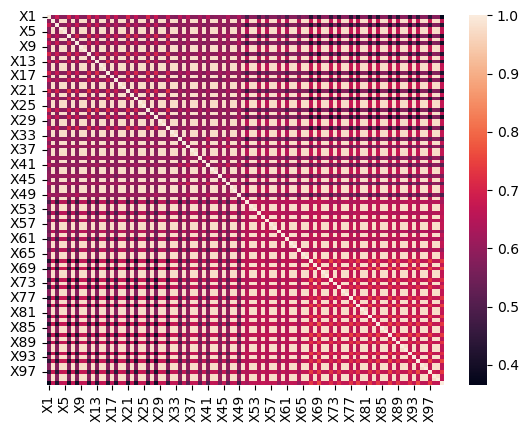

In [35]:
corr_ = data.drop(columns=['y_conti', 'y_binary', 'group']).corr()
sns.heatmap(data=corr_)

In [36]:
data

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X94,X95,X96,X97,X98,X99,X100,y_conti,y_binary,group
0,-4.132656,-4.034711,-4.069552,-4.012707,-4.251853,-4.118396,-4.690228,-4.375615,-4.492534,-4.126158,...,-4.254302,-4.444565,-4.306496,-4.228754,-4.476662,-4.083745,-4.407986,-4.864393,1,linear
1,-5.019707,-5.365852,-5.397459,-5.602813,-5.457476,-5.121880,-5.316252,-5.342888,-5.148427,-4.934305,...,-5.450104,-5.251996,-6.069397,-5.249519,-5.208546,-5.126032,-5.204191,-4.493474,0,linear
2,-4.153804,-4.548141,-4.206143,-3.822426,-3.883242,-3.823074,-4.366626,-4.057430,-4.017438,-3.971733,...,-3.849137,-4.086597,-3.756277,-4.087797,-3.861696,-3.777078,-3.863813,-3.510912,1,linear
3,-3.929308,-3.856792,-3.699859,-3.773893,-3.736561,-3.554277,-3.371539,-3.514151,-3.868615,-3.792072,...,-3.267275,-3.902080,-3.683562,-3.699186,-4.059673,-3.772678,-3.623362,-3.993737,1,linear
4,-4.887089,-4.028260,-4.299598,-4.074515,-4.243070,-4.654626,-4.957813,-4.842468,-4.046203,-4.460014,...,-4.212560,-4.282438,-4.471305,-4.661115,-4.861462,-4.471436,-4.237133,-4.294174,1,linear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,-2.327597,4.400811,-2.576293,3.790832,4.317059,-2.322418,4.205037,-0.746625,5.160183,4.237534,...,3.579443,4.723499,3.928274,2.912568,3.997825,4.478443,3.162839,5.763336,1,trig
1496,-1.946054,4.613390,-2.584399,3.591543,4.377012,4.523517,5.008166,3.701827,4.556541,5.021581,...,4.520693,4.717935,5.214622,4.420846,4.140251,5.106667,3.257848,6.217859,1,trig
1497,-2.043695,4.023643,3.930006,4.162933,4.448610,-1.915535,3.972699,1.209890,3.820798,4.572966,...,4.476523,4.407449,3.985761,-0.437211,5.275750,4.113790,1.538276,4.350327,0,trig
1498,-0.605166,4.386993,2.504039,3.537586,4.406641,3.558778,3.969096,-2.355404,3.837996,4.372986,...,1.769077,4.818923,3.996685,3.662400,4.737548,5.042113,-1.995294,4.855022,1,trig


In [37]:
X = data.drop(columns=['y_conti', 'y_binary', 'group'])
y = data['y_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

rfc = RandomForestClassifier(n_estimators=300, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.15      0.52      0.24        44
           1       0.91      0.61      0.73       331

    accuracy                           0.60       375
   macro avg       0.53      0.57      0.48       375
weighted avg       0.82      0.60      0.67       375



In [38]:
# X.to_csv('generatedata.csv', sep='\t', index=False)

In [39]:
data['filename'] = [f'{i}' for i in range(1, 1501)]
data['filename'] = data['filename'].astype(int)
# banknote = banknote.drop(columns=['class'])
# churn.to_csv('churn.csv', sep='\t', encoding='utf-8', index=False) 
data_order = pd.read_csv(r"C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\gap_生成.txt", sep='\t')
raw = '8  7  8  7  8  7  6  8  7  7  7  7  7  8  6  8  6  7  8  7  8  8  8  7  8  8  6  7  7  7  7  7  7  7  7  7  7  6  7  6  8  6  7  7  8  7  7  7  7  6  8  7  6  7  7  8  7  7  6  6  7  7  7  8  8  8  7  7  7  6  8  7  7  7  6  7  7  7  7  8  7  7  7  7  8  6  7  6  6  7  7  7  7  6  7  7  7  8  6  7  7  6  7  7  8  6  7  7  7  8  6  8  7  7  7  8  7  6  7  7  8  6  7  7  7  8  6  7  6  7  8  8  6  6  7  6  7  7  6  7  6  6  7  6  8  8  6  7  7  7  8  8  7  7  6  8  7  7  8  7  8  7  8  7  7  8  7  7  8  6  7  6  7  7  8  8  8  8  6  8  7  7  7  6  7  7  8  6  7  7  6  7  7  7  8  6  7  8  8  6  6  7  7  6  7  8  6  7  6  7  8  6  8  7  7  7  7  6  7  7  8  6  7  7  6  8  8  8  8  7  6  7  7  8  8  8  7  7  7  8  7  8  7  7  7  7  8  8  7  7  7  8  8  6  7  6  7  6  8  8  6  6  8  6  6  6  7  7  7  6  7  7  7  8  7  7  6  6  7  8  8  8  7  8  7  7  6  7  7  7  7  7  8  6  7  7  8  6  7  7  6  7  7  6  7  6  8  6  7  8  7  7  8  7  7  8  8  7  7  7  7  7  6  8  8  6  7  7  7  8  7  6  8  7  7  7  8  7  7  8  8  7  7  8  7  7  7  8  8  6  8  6  6  7  8  6  7  8  6  6  6  7  6  7  7  7  7  7  8  8  6  7  6  7  7  7  7  6  7  7  7  8  7  7  6  8  7  6  7  7  7  6  7  8  7  8  7  8  8  8  8  8  7  7  8  7  6  7  7  7  8  8  7  6  7  7  6  7  7  7  6  7  8  7  8  6  6  7  6  6  8  7  8  7  7  7  7  6  7  6  7  6  7  8  8  7  7  7  7  7  8  8  8  6  6  7  7  7  7  7  7  8  7  6  7  6  7  6  6  6  7  7  7  7  6  7  6  7  8  7  7  8  7  8  2  7  7  8  7  7  7  6  7  7  7  8  7  7  8  7  1  2  0  1  0  1  2  1  1  1  0  0  0  1  0  1  0  1  0  0  1  1  1  2  1  1  1  0  0  2  0  2  0  1  0  2  0  1  1  2  2  2  2  1  1  1  0  0  0  1  1  1  1  1  2  0  2  1  1  2  0  0  0  0  0  0  0  2  1  2  2  0  0  2  0  0  1  0  2  1  1  0  0  0  2  0  0  1  1  0  1  1  1  1  2  2  2  2  0  1  2  1  0  2  2  0  0  2  0  2  2  2  0  1  0  0  1  1  1  0  2  0  1  0  1  2  1  1  0  2  1  1  0  0  0  1  0  1  1  1  1  1  1  1  0  2  0  2  0  0  1  1  0  0  0  1  2  0  1  0  2  1  1  1  1  0  0  1  0  2  0  0  1  2  1  0  1  1  0  1  0  2  1  0  1  2  1  2  1  1  1  0  1  0  2  0  2  0  2  1  0  2  1  0  1  1  0  0  1  1  0  0  0  0  2  1  1  0  1  0  2  2  2  0  1  1  2  1  1  1  2  1  1  1  0  1  1  0  2  0  1  0  1  0  0  0  0  0  0  0  2  0  0  2  0  1  1  1  0  1  0  2  1  0  0  2  0  0  1  1  2  0  0  0  1  0  1  1  0  0  1  2  1  0  2  0  0  1  1  0  0  0  0  1  1  0  0  2  1  1  1  0  0  2  0  0  1  1  1  1  1  0  2  1  0  1  1  2  2  1  0  1  0  0  1  1  0  0  1  1  2  0  0  1  2  1  1  1  0  1  1  2  0  0  0  1  0  0  2  1  0  1  2  1  0  1  2  0  1  2  0  2  1  1  0  0  0  1  2  1  0  0  1  0  0  2  2  2  2  1  0  1  1  0  1  2  2  1  0  2  0  0  0  0  0  1  0  1  0  2  0  0  1  0  0  1  0  2  0  2  1  2  1  1  1  1  2  0  0  0  2  2  1  1  0  2  1  1  2  1  2  1  1  2  0  1  0  2  1  2  1  2  1  0  1  1  1  1  1  2  2  1  0  0  0  1  1  0  0  0  1  2  1  0  2  1  1  1  0  1  0  0  1  1  1  1  0  1  0  0  1  0  1  0  0  2  2  0  2  2  2  1  0  2  1  1  2  1  1  2  5  3  5  3  4  4  5  3  3  3  4  5  3  5  4  5  4  3  3  3  5  5  5  5  4  3  5  3  3  4  5  3  4  5  3  3  5  5  3  5  4  3  3  4  3  3  3  3  5  5  5  3  4  3  5  3  5  3  5  3  3  4  3  3  3  5  3  3  3  3  5  3  4  4  4  5  3  3  5  3  3  4  3  3  3  5  4  3  4  4  3  5  4  5  5  5  5  3  5  5  3  5  3  5  5  3  5  5  5  5  4  5  3  5  4  3  4  5  4  5  4  3  4  3  3  3  3  5  4  4  3  5  4  3  5  5  3  3  5  5  3  4  3  5  5  4  3  5  4  4  3  3  3  5  5  5  5  5  4  3  5  4  3  5  5  3  5  3  5  3  5  4  4  5  3  5  3  3  5  3  4  3  4  4  3  4  3  3  4  5  5  5  3  3  3  4  4  5  4  3  3  4  5  3  5  4  4  4  5  3  3  3  5  4  3  5  3  3  4  5  3  3  4  4  4  3  3  5  3  4  3  5  4  4  5  3  3  5  5  4  4  3  4  3  4  4  5  4  5  4  5  3  3  5  3  3  5  5  4  3  3  3  4  3  5  3  3  4  4  5  5  4  3  5  4  5  4  5  4  4  3  3  6  4  5  5  5  3  3  5  3  4  3  3  3  3  3  4  5  5  3  4  3  4  3  3  5  4  3  3  5  3  5  3  3  3  5  5  4  5  4  5  3  5  4  5  3  5  5  3  3  4  4  4  3  4  3  4  3  3  3  3  3  5  3  4  4  5  4  5  3  3  3  4  3  4  4  3  3  4  5  3  5  4  4  4  3  4  3  4  4  5  3  5  3  3  3  3  3  5  3  3  5  4  5  5  4  3  3  5  3  3  3  5  4  5  3  3  4  5  4  5  5  4  3  3  4  5  3  3  5  3  3  3  5  4  4  4  3  3  5  5  3  5  4  3  3  5  5  5  5  5  3  5  3  3  3  5  5  3  4  5  4  5  4  4  3  4  5  3  3  3  3  5  3  4  3  5  5  3  4  5  5  3  4  3  3  5  5  3  5  5  5  5  4  5  4  3  3  5  3  5  5  3  3  3  3  4  3  3  3  5  3  3  3  3  3  5  4  3'
raw_list = [int(i) for i in raw.split()]
data_order['gap_cluster'] = raw_list
data_order['filename'] = data_order['UNIQID'].str.lstrip('r').astype('int')+1
data_order = data_order.drop(columns=['UNIQID'])

data_merged = pd.merge(data, data_order[['gap_cluster', 'filename']], on='filename').drop(columns=['filename'])


In [40]:
data_merged

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X95,X96,X97,X98,X99,X100,y_conti,y_binary,group,gap_cluster
0,-4.132656,-4.034711,-4.069552,-4.012707,-4.251853,-4.118396,-4.690228,-4.375615,-4.492534,-4.126158,...,-4.444565,-4.306496,-4.228754,-4.476662,-4.083745,-4.407986,-4.864393,1,linear,3
1,-5.019707,-5.365852,-5.397459,-5.602813,-5.457476,-5.121880,-5.316252,-5.342888,-5.148427,-4.934305,...,-5.251996,-6.069397,-5.249519,-5.208546,-5.126032,-5.204191,-4.493474,0,linear,5
2,-4.153804,-4.548141,-4.206143,-3.822426,-3.883242,-3.823074,-4.366626,-4.057430,-4.017438,-3.971733,...,-4.086597,-3.756277,-4.087797,-3.861696,-3.777078,-3.863813,-3.510912,1,linear,3
3,-3.929308,-3.856792,-3.699859,-3.773893,-3.736561,-3.554277,-3.371539,-3.514151,-3.868615,-3.792072,...,-3.902080,-3.683562,-3.699186,-4.059673,-3.772678,-3.623362,-3.993737,1,linear,5
4,-4.887089,-4.028260,-4.299598,-4.074515,-4.243070,-4.654626,-4.957813,-4.842468,-4.046203,-4.460014,...,-4.282438,-4.471305,-4.661115,-4.861462,-4.471436,-4.237133,-4.294174,1,linear,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,-2.327597,4.400811,-2.576293,3.790832,4.317059,-2.322418,4.205037,-0.746625,5.160183,4.237534,...,4.723499,3.928274,2.912568,3.997825,4.478443,3.162839,5.763336,1,trig,0
1496,-1.946054,4.613390,-2.584399,3.591543,4.377012,4.523517,5.008166,3.701827,4.556541,5.021581,...,4.717935,5.214622,4.420846,4.140251,5.106667,3.257848,6.217859,1,trig,2
1497,-2.043695,4.023643,3.930006,4.162933,4.448610,-1.915535,3.972699,1.209890,3.820798,4.572966,...,4.407449,3.985761,-0.437211,5.275750,4.113790,1.538276,4.350327,0,trig,0
1498,-0.605166,4.386993,2.504039,3.537586,4.406641,3.558778,3.969096,-2.355404,3.837996,4.372986,...,4.818923,3.996685,3.662400,4.737548,5.042113,-1.995294,4.855022,1,trig,0


In [41]:
# X = 特徵, y = 目標
X = data_merged.drop(columns=['y_conti', 'y_binary', 'group', 'gap_cluster'])
y = data_merged['y_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [54]:
# === 1) Linear Regression ===
lir_ = LinearRegression()
model1 = lir_.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
y_pred1_cls = (y_pred1 >= 0.5).astype(int)
print("\n=== Linear Regression ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred1_cls, digits=4))


=== Linear Regression ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.3818    0.1750    0.2400       120
           1     0.5959    0.8111    0.6871       180

    accuracy                         0.5567       300
   macro avg     0.4889    0.4931    0.4635       300
weighted avg     0.5103    0.5567    0.5082       300



In [55]:
# === 2) Linear SVC ===
lsvc = LinearSVC(random_state=42, class_weight='balanced')
model2 = lsvc.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
print("\n=== Linear SVC ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred2, digits=4))


=== Linear SVC ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.3250    0.3250    0.3250       120
           1     0.5500    0.5500    0.5500       180

    accuracy                         0.4600       300
   macro avg     0.4375    0.4375    0.4375       300
weighted avg     0.4600    0.4600    0.4600       300



In [56]:
# === 3) Kernel SVC ===
rbfsvc = SVC(kernel='rbf', random_state=42, class_weight='balanced')
model3 = rbfsvc.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)
print("\n=== Kernel SVC ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred3, digits=4))


=== Kernel SVC ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.4486    0.4000    0.4229       120
           1     0.6269    0.6722    0.6488       180

    accuracy                         0.5633       300
   macro avg     0.5378    0.5361    0.5359       300
weighted avg     0.5556    0.5633    0.5584       300



In [57]:
# === 4) RandomForestClassifier ===
rfc = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
model4 = rfc.fit(X_train, y_train)
y_pred4 = model4.predict(X_test)
print("\n=== RandomForestClassifier ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred4, digits=4))


=== RandomForestClassifier ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.5185    0.2333    0.3218       120
           1     0.6260    0.8556    0.7230       180

    accuracy                         0.6067       300
   macro avg     0.5723    0.5444    0.5224       300
weighted avg     0.5830    0.6067    0.5625       300



In [58]:
# === 5) XGBoost ===
xgb = XGBClassifier(random_state=42, n_jobs=-1)
model5 = xgb.fit(X_train, y_train)
y_pred5 = model5.predict(X_test)
print("\n=== XGBoost ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred5, digits=4))


=== XGBoost ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.3659    0.2500    0.2970       120
           1     0.5872    0.7111    0.6432       180

    accuracy                         0.5267       300
   macro avg     0.4765    0.4806    0.4701       300
weighted avg     0.4986    0.5267    0.5047       300



In [59]:
# # === 6) LightGBM ===
lgbm = LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
model6 = lgbm.fit(X_train, y_train)
y_pred6 = model6.predict(X_test)
print("\n=== LightGBM ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred6, digits=4))


=== LightGBM ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.3529    0.2500    0.2927       120
           1     0.5814    0.6944    0.6329       180

    accuracy                         0.5167       300
   macro avg     0.4672    0.4722    0.4628       300
weighted avg     0.4900    0.5167    0.4968       300



In [45]:
data_merged

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X95,X96,X97,X98,X99,X100,y_conti,y_binary,group,gap_cluster
0,-4.132656,-4.034711,-4.069552,-4.012707,-4.251853,-4.118396,-4.690228,-4.375615,-4.492534,-4.126158,...,-4.444565,-4.306496,-4.228754,-4.476662,-4.083745,-4.407986,-4.864393,1,linear,3
1,-5.019707,-5.365852,-5.397459,-5.602813,-5.457476,-5.121880,-5.316252,-5.342888,-5.148427,-4.934305,...,-5.251996,-6.069397,-5.249519,-5.208546,-5.126032,-5.204191,-4.493474,0,linear,5
2,-4.153804,-4.548141,-4.206143,-3.822426,-3.883242,-3.823074,-4.366626,-4.057430,-4.017438,-3.971733,...,-4.086597,-3.756277,-4.087797,-3.861696,-3.777078,-3.863813,-3.510912,1,linear,3
3,-3.929308,-3.856792,-3.699859,-3.773893,-3.736561,-3.554277,-3.371539,-3.514151,-3.868615,-3.792072,...,-3.902080,-3.683562,-3.699186,-4.059673,-3.772678,-3.623362,-3.993737,1,linear,5
4,-4.887089,-4.028260,-4.299598,-4.074515,-4.243070,-4.654626,-4.957813,-4.842468,-4.046203,-4.460014,...,-4.282438,-4.471305,-4.661115,-4.861462,-4.471436,-4.237133,-4.294174,1,linear,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,-2.327597,4.400811,-2.576293,3.790832,4.317059,-2.322418,4.205037,-0.746625,5.160183,4.237534,...,4.723499,3.928274,2.912568,3.997825,4.478443,3.162839,5.763336,1,trig,0
1496,-1.946054,4.613390,-2.584399,3.591543,4.377012,4.523517,5.008166,3.701827,4.556541,5.021581,...,4.717935,5.214622,4.420846,4.140251,5.106667,3.257848,6.217859,1,trig,2
1497,-2.043695,4.023643,3.930006,4.162933,4.448610,-1.915535,3.972699,1.209890,3.820798,4.572966,...,4.407449,3.985761,-0.437211,5.275750,4.113790,1.538276,4.350327,0,trig,0
1498,-0.605166,4.386993,2.504039,3.537586,4.406641,3.558778,3.969096,-2.355404,3.837996,4.372986,...,4.818923,3.996685,3.662400,4.737548,5.042113,-1.995294,4.855022,1,trig,0


In [46]:
y_col = 'y_binary'
c_col = 'gap_cluster'
X = data_merged.drop(columns=['y_conti', 'y_binary', 'group', 'gap_cluster'])
y = data_merged[y_col]
c = data_merged[c_col]

strat_key = y.astype(str) + '|' + c.astype(str)
X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(X, y, c, test_size=0.2, stratify=strat_key, random_state=42)

labels_all = np.sort(y.unique())
rows = []
confusion_matrix_= {}
classification_report_ = {}
for k in sorted(c_train.unique()):
    train_mask = (c_train == k)
    test_mask = (c_test == k)
    Xk_train, yk_train = X_train[train_mask], y_train[train_mask]
    Xk_test, yk_test = X_test[test_mask], y_test[test_mask]

    if len(yk_train.unique())<2 or len(yk_test)==0:
        rows.append({'cluster':k, 'n_train':len(yk_train), 'n_test':len(yk_test), 'Acc':np.nan, 'F1':np.nan, 'note':'類別不足或無測試樣本'})
        continue

    lir_ = LinearRegression()
    lir_.fit(Xk_train, yk_train)
    lir_y_score = lir_.predict(Xk_test)
    lir_y_hat = (lir_y_score>=0.5).astype(int)
    rows.append({'cluster':k, 'model':'linear_0.5', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'linear_0.5')] = classification_report(yk_test, lir_y_hat, digits=4)

    lsvc = LinearSVC(random_state=42, class_weight='balanced')
    lsvc.fit(Xk_train, yk_train)
    lsvc__y_hat = lsvc.predict(Xk_test)
    lsvc__y_prob = lsvc.decision_function(Xk_test)
    rows.append({'cluster':k, 'model':'lsvc', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'LinearSVC')] = classification_report(yk_test, lsvc__y_hat)

    rbfsvc = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    rbfsvc.fit(Xk_train, yk_train)
    rbfsvc__y_hat = lsvc.predict(Xk_test)
    rbfsvc__y_prob = lsvc.decision_function(Xk_test)
    rows.append({'cluster':k, 'model':'rbfsvc', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'KernelSVC')] = classification_report(yk_test, rbfsvc__y_hat)


    rfc = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
    rfc.fit(Xk_train, yk_train)
    rfc_y_hat = rfc.predict(Xk_test)
    rfc__y_proba = rfc.predict_proba(Xk_test)[:,1]
    rows.append({'cluster':k, 'model':'rfc', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'RandomForestClassifier')] = classification_report(yk_test, rfc_y_hat)

    xgbc = XGBClassifier(random_state=42, n_jobs=-1)
    xgbc.fit(Xk_train, yk_train)
    xgbc_y_hat = xgbc.predict(Xk_test)
    xgbc__y_proba = xgbc.predict_proba(Xk_test)[:,1]
    rows.append({'cluster':k, 'model':'xgbc', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'XGBClassifier')] = classification_report(yk_test, xgbc_y_hat)

    lgbmc = LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced', verbose=-1)
    lgbmc.fit(Xk_train, yk_train)
    lgbmc_y_hat = lgbmc.predict(Xk_test)
    lgbmc__y_proba = lgbmc.predict_proba(Xk_test)[:,1]
    rows.append({'cluster':k, 'model':'lgbmc', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'LGBMClassifier')] = classification_report(yk_test, lgbmc_y_hat)

report = pd.DataFrame(rows).sort_values(['cluster','model'])
report

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

,cluster,model,n_train,n_test
5,0,lgbmc,154,38
0,0,linear_0.5,154,38
1,0,lsvc,154,38
2,0,rbfsvc,154,38
3,0,rfc,154,38
4,0,xgbc,154,38
11,1,lgbmc,160,41
6,1,linear_0.5,160,41
7,1,lsvc,160,41
8,1,rbfsvc,160,41


In [48]:
print(classification_report_[(0, 'linear_0.5')])
print(classification_report_[(0, 'LinearSVC')])
print(classification_report_[(0, 'KernelSVC')])
print(classification_report_[(0, 'XGBClassifier')])

              precision    recall  f1-score   support

           0     0.4000    0.6154    0.4848        13
           1     0.7222    0.5200    0.6047        25

    accuracy                         0.5526        38
   macro avg     0.5611    0.5677    0.5447        38
weighted avg     0.6120    0.5526    0.5637        38

              precision    recall  f1-score   support

           0       0.33      0.54      0.41        13
           1       0.65      0.44      0.52        25

    accuracy                           0.47        38
   macro avg       0.49      0.49      0.47        38
weighted avg       0.54      0.47      0.49        38

              precision    recall  f1-score   support

           0       0.33      0.54      0.41        13
           1       0.65      0.44      0.52        25

    accuracy                           0.47        38
   macro avg       0.49      0.49      0.47        38
weighted avg       0.54      0.47      0.49        38

              preci

---
---

In [29]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')

# 準備 X, y
X = secom.drop(columns=['Time', 'Pass/Fail']).apply(pd.to_numeric, errors='coerce')
y = secom['Pass/Fail'].replace({-1:1, 1:0}).astype('int')

# (1) 移除缺失 > 1000 的特徵
na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()

# (2) 切分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# (3) KNN 填補（k=10）
imputer = KNNImputer(n_neighbors=10)
X_tr_impute = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_te_impute = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# (4) 隨機森林重要度：取前 140 特徵
rfc = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rfc.fit(X_tr_impute, y_train)
X_impute_series = pd.Series(rfc.feature_importances_, index=X_tr_impute.columns).sort_values(ascending=False)
top_k = X_impute_series.index[:140].tolist()

X_tr_top = X_tr_impute[top_k].copy()
X_te_top = X_te_impute[top_k].copy()

# 5) SMOTE（sampling_strategy=0.5）
smote = SMOTE(sampling_strategy=0.8, k_neighbors=5, random_state=42)
X_tr_balanced, y_tr_balanced = smote.fit_resample(X_tr_top, y_train)

# (6) 決策樹（gini、max_depth=6）
dtc = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
dtc.fit(X_tr_balanced, y_tr_balanced)

y_pred = dtc.predict(X_te_top)
y_prob = dtc.predict_proba(X_te_top)[:, 1] # 以「1」為正類計算 ROC-AUC
auc_roc = roc_auc_score(y_test, y_prob)

print("\n=== Decision Tree (criterion=gini, max_depth=6) ===")

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", round(auc_roc, 6))

cm = confusion_matrix(y_test, y_pred, labels=[0,1])  # [[TN, FP],[FN, TP]]
TP, FN, FP, TN = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
far = FP / (FP + TN) if (FP + TN) > 0 else np.nan
print("Confusion Matrix:\n", cm)
print("FAR (False Alarm Rate = FP/(FP+TN)):", round(far*100, 2), "%")



=== Decision Tree (criterion=gini, max_depth=6) ===
              precision    recall  f1-score   support

           0     0.1176    0.2857    0.1667        21
           1     0.9430    0.8464    0.8921       293

    accuracy                         0.8089       314
   macro avg     0.5303    0.5661    0.5294       314
weighted avg     0.8878    0.8089    0.8436       314

ROC-AUC: 0.413944
Confusion Matrix:
 [[  6  15]
 [ 45 248]]
FAR (False Alarm Rate = FP/(FP+TN)): 15.36 %


In [30]:
y_tr_balanced.value_counts()

Pass/Fail
1    1170
0     936
Name: count, dtype: int64

In [17]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')

# 準備 X, y
X = secom.drop(columns=['Time', 'Pass/Fail'], errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce')
y = secom['Pass/Fail'].replace({-1:1, 1:0}).astype('int')

# (1) 移除缺失 > 1000 的特徵
na_counts = X.isna().sum()
cols_keep = na_counts[na_counts<=1000].index.tolist()
X = X[cols_keep]
X = X.loc[:, X.notna().any(axis=0)]

# (2) KNN 填補（k=10）
imputer = KNNImputer(n_neighbors=10,  weights='distance')
X_impute = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=secom.index)

# (3) 隨機森林重要度：取前 140 特徵
rfc = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced')
rfc.fit(X_impute, y)
X_impute_series = pd.Series(rfc.feature_importances_, index=X_impute.columns).sort_values(ascending=False)

top_k = min(140, X_impute_series.shape[0])
selected_cols = X_impute_series.index[:top_k].tolist()
X_top140 = X_impute[selected_cols].copy()
secom_top140 = pd.concat([X_top140, y.rename("label")], axis=1)

X = secom_top140.drop(columns=["label"])
y = secom_top140["label"].astype(int)

# (4) 切分 → 縮放 → SMOTE（只在訓練集）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("原始類別分佈(Train)：", dict(zip(*np.unique(y_train, return_counts=True))))

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)
X_te_scaled = scaler.transform(X_test)

n_min = y_train.value_counts().min()
k_smote = min(10, max(2, n_min-1))
smote = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote, random_state=42)
X_tr_balanced, y_tr_balanced = smote.fit_resample(X_tr_scaled, y_train)
print("SMOTE 後類別分佈(Train)：", dict(zip(*np.unique(y_tr_balanced, return_counts=True))))

# (5) 決策樹（gini、max_depth=6）
dtc = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
dtc.fit(X_tr_balanced, y_tr_balanced)

y_pred = dtc.predict(X_te_scaled)
y_prob = dtc.predict_proba(X_te_scaled)[:, 1] # 以「1」為正類計算 ROC-AUC
auc_roc = roc_auc_score(y_test, y_prob)

print("\n=== Decision Tree (criterion=gini, max_depth=6) ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", round(auc_roc, 6))

cm = confusion_matrix(y_test, y_pred, labels=[0,1])  # [[TN, FP],[FN, TP]]
TP, FN, FP, TN = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
far = FP / (FP + TN) if (FP + TN) > 0 else np.nan
print("Confusion Matrix:\n", cm)
print("FAR (False Alarm Rate = FP/(FP+TN)):", round(far*100, 2), "%")

原始類別分佈(Train)： {0: 83, 1: 1170}
SMOTE 後類別分佈(Train)： {0: 1170, 1: 1170}

=== Decision Tree (criterion=gini, max_depth=6) ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.1216    0.4286    0.1895        21
           1     0.9500    0.7782    0.8555       293

    accuracy                         0.7548       314
   macro avg     0.5358    0.6034    0.5225       314
weighted avg     0.8946    0.7548    0.8110       314

ROC-AUC: 0.571185
Confusion Matrix:
 [[  9  12]
 [ 65 228]]
FAR (False Alarm Rate = FP/(FP+TN)): 22.18 %


In [11]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(cm)
# 把 0 視為「警報」
FP = cm[0, 1]  # true=0, pred=1
TN = cm[0, 0]  # true=0, pred=0
FAR = FP / (FP + TN) if (FP + TN) > 0 else np.nan
print('0->0:9(TN), 1->0:65(FN), 0->1:12(FP), 1->1:228(TP)')
print('FAR = FP/(FP+TN)')
print("False Alarm Rate (alarm=class 0):", round(FAR, 6))



[[  9  12]
 [ 65 228]]
0->0:9(TN), 1->0:65(FN), 0->1:12(FP), 1->1:228(TP)
FAR = FP/(FP+TN)
False Alarm Rate (alarm=class 0): 0.571429


In [113]:
# secom['Time'] = pd.to_datetime(secom['Time'], errors='coerce')
# secom['class'] = secom['Pass/Fail'].map({-1:'Pass', 1:'Fail'})
# counts = (secom.set_index('Time').groupby([pd.Grouper(freq='D'), 'class']).size().unstack(fill_value=0)) # 'D'=天, 'H'=小時, 'W'=週
# smooth = counts.rolling(7, min_periods=1).mean()

# ax = counts.plot(figsize=(8, 6))
# ax.set_title('Pass/Fail')
# ax.set_xlabel('Time')
# ax.set_ylabel('Counts')
# ax.legend(title='')
# plt.tight_layout()
# plt.show()

# ax = smooth.plot(figsize=(8, 6))
# ax.set_title('Pass/Fail smooth')
# ax.set_xlabel('Time')
# ax.set_ylabel('Counts')
# ax.legend(title='')
# plt.tight_layout()
# plt.show()

In [114]:
# fail_rate = counts['Fail']/counts.sum(axis=1)
# fail_rate_ma7 = fail_rate.rolling(7, min_periods=1).mean()

# ax = fail_rate_ma7.plot(figsize=(8, 6))
# ax.set_title('fail_rate smooth')
# ax.set_xlabel('Time')
# ax.set_ylabel('Counts')
# ax.legend(title='')
# plt.tight_layout()
# plt.show()

In [143]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')

secom = secom.replace(['NaN'], np.nan)
numeric_cols = secom.drop(columns=['Time', 'Pass/Fail']).select_dtypes(include=[np.number]).columns.tolist()
knn = KNNImputer(n_neighbors=10, weights='distance')
secom[numeric_cols] = knn.fit_transform(secom[numeric_cols])

secom['Pass/Fail'] = secom['Pass/Fail'].replace({-1:1, 1:0})
# X = 特徵, y = 目標
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [144]:
# === 1) Linear Regression ===
lir_ = LinearRegression()
model1 = lir_.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
y_pred1_cls = (y_pred1 >= 0.5).astype(int)
print("\n=== Linear Regression ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred1_cls, digits=4))



=== Linear Regression ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.3158    0.1935    0.2400        31
           1     0.9447    0.9705    0.9574       440

    accuracy                         0.9193       471
   macro avg     0.6302    0.5820    0.5987       471
weighted avg     0.9033    0.9193    0.9102       471



In [145]:
# === 3) Kernel SVC ===
rbfsvc = SVC(kernel='rbf', random_state=42, class_weight='balanced')
model3 = rbfsvc.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)
print("\n=== Kernel SVC ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred3, digits=4))


=== Kernel SVC ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.0870    0.3871    0.1420        31
           1     0.9429    0.7136    0.8124       440

    accuracy                         0.6921       471
   macro avg     0.5149    0.5504    0.4772       471
weighted avg     0.8866    0.6921    0.7683       471



In [147]:
# === 4) RandomForestClassifier ===
rfc = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
model4 = rfc.fit(X_train, y_train)
y_pred4 = model4.predict(X_test)
y_prob4 = rfc.predict_proba(X_test)[:, 1]
auc_roc4 = roc_auc_score(y_test, y_prob4)
print("\n=== RandomForestClassifier ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred4, digits=4))
print("ROC-AUC:", round(auc_roc4, 6))



=== RandomForestClassifier ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        31
           1     0.9342    1.0000    0.9660       440

    accuracy                         0.9342       471
   macro avg     0.4671    0.5000    0.4830       471
weighted avg     0.8727    0.9342    0.9024       471

ROC-AUC: 0.754032


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [110]:
# === 5) XGBoost ===
xgb = XGBClassifier(random_state=42, n_jobs=-1)
model5 = xgb.fit(X_train, y_train)
y_pred5 = model5.predict(X_test)
print("\n=== XGBoost ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred5, digits=4))


=== XGBoost ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        31
           1     0.9340    0.9977    0.9648       440

    accuracy                         0.9321       471
   macro avg     0.4670    0.4989    0.4824       471
weighted avg     0.8726    0.9321    0.9013       471



In [112]:
# 確保 y 僅有 {0,1}，且此處少數類是 0
n0 = (y_train == 0).sum()
n1 = (y_train == 1).sum()

# 1) 以 sample_weight 提高少數類(0)權重
w0 = n1 / n0
sw = np.where(y_train == 0, w0, 1.0)

clf = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric="aucpr",      # PR-AUC 對不平衡較合理
    n_jobs=-1,
    random_state=42
)

clf.fit(
    X_train, y_train,
    sample_weight=sw,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 2) 調整決策閾值：直接對「類別0的機率」做 PR 曲線，找 F1 最大點
proba_cls0 = clf.predict_proba(X_test)[:, 0]  # 類別0的機率
precision, recall, thresholds = precision_recall_curve((y_test==0).astype(int), proba_cls0)
f1 = (2*precision*recall)/(precision+recall+1e-12)
best_i = f1.argmax()
thr = thresholds[best_i]

# 以此閾值做預測（>=thr 視為類別0，否則 1）
y_pred = np.where(proba_cls0 >= thr, 0, 1)

print(f"選到的閾值(threshold) = {thr:.4f}")
print(classification_report(y_test, y_pred, digits=4))
print("balanced_accuracy:", balanced_accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

選到的閾值(threshold) = 0.0119
              precision    recall  f1-score   support

           0     0.1977    0.5484    0.2906        31
           1     0.9636    0.8432    0.8994       440

    accuracy                         0.8238       471
   macro avg     0.5807    0.6958    0.5950       471
weighted avg     0.9132    0.8238    0.8593       471

balanced_accuracy: 0.6957844574780059
[[ 17  14]
 [ 69 371]]
